In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

POLICY_DATE = pd.Timestamp("2025-01-05")

# Same DATA_DIR logic as step 1 (Drive on Colab, else local)
def resolve_data_dir():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        return "/content/drive/MyDrive/nyc-crz-counterfactual"
    except Exception:
        return "./nyc-crz-counterfactual"

DATA_DIR   = resolve_data_dir()
PANEL_PATH = os.path.join(DATA_DIR, "crz_hourly_panel_yellow.parquet")

panel = pd.read_parquet(PANEL_PATH)
panel["datetime"] = pd.to_datetime(panel["datetime"])
panel = panel.sort_values(["datetime", "group"]).reset_index(drop=True)
print("Loaded:", panel.shape, "|", panel.datetime.min(), "->", panel.datetime.max())
panel.head()

Mounted at /content/drive
Loaded: (52602, 7) | 2023-01-01 00:00:00 -> 2025-12-31 23:00:00


,datetime,group,n_trips,dur_mean_min,dur_median_min,speed_mean_mph,speed_median_mph
0,2023-01-01 00:00:00,control,1436,12.344835,9.541667,16.468969,13.529896
1,2023-01-01 00:00:00,treated,3713,16.021901,13.933333,11.414389,10.396484
2,2023-01-01 01:00:00,control,1556,12.464128,9.491667,15.041825,13.033694
3,2023-01-01 01:00:00,treated,3926,15.678078,13.958333,11.990438,11.280086
4,2023-01-01 02:00:00,control,1147,12.714211,10.433333,15.298440,13.647059


In [ ]:
# Monthly totals/means per group, plus YoY growth
m = (panel.assign(month=panel.datetime.dt.to_period("M"))
          .groupby(["month", "group"])
          .agg(trips=("n_trips", "sum"),
               speed=("speed_median_mph", "mean"),
               dur=("dur_median_min", "mean"))
          .reset_index())
m["month"] = m["month"].dt.to_timestamp()

def yoy_table(m):
    wide = m.pivot(index="month", columns="group", values="trips")
    out = pd.DataFrame(index=sorted(m.month.dt.year.unique()))
    for g in ["treated", "control"]:
        yr = wide[g].groupby(wide.index.year).mean()
        out[f"{g}_avg_trips"] = yr
        out[f"{g}_YoY%"] = (yr.pct_change() * 100).round(1)
    return out

print(yoy_table(m).to_string())

      treated_avg_trips  treated_YoY%  control_avg_trips  control_YoY%
2023       2.278272e+06           NaN       7.984248e+05           NaN
2024       2.453610e+06           7.7       8.771618e+05           9.9
2025       2.784322e+06          13.5       1.083818e+06          23.6


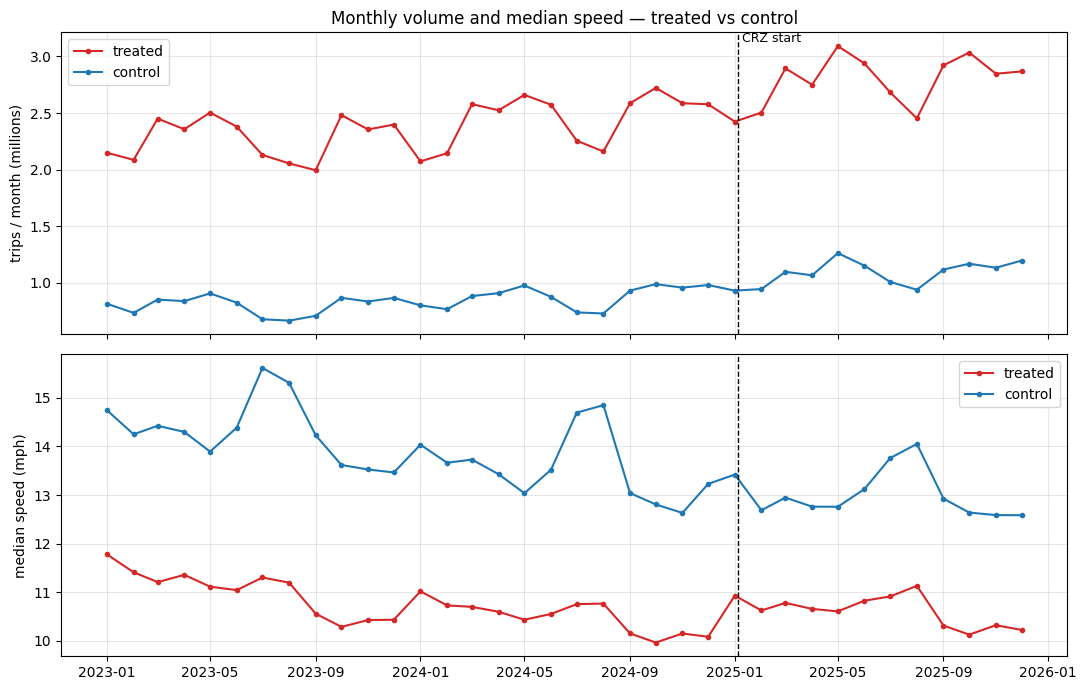

In [ ]:
def plot_levels(m):
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for g, c in [("treated", "tab:red"), ("control", "tab:blue")]:
        d = m[m.group == g]
        axes[0].plot(d.month, d.trips / 1e6, label=g, color=c, marker=".")
        axes[1].plot(d.month, d.speed, label=g, color=c, marker=".")
    for ax in axes:
        ax.axvline(POLICY_DATE, color="k", ls="--", lw=1)
        ax.legend(); ax.grid(alpha=.3)
    axes[0].set_ylabel("trips / month (millions)")
    axes[1].set_ylabel("median speed (mph)")
    axes[0].text(POLICY_DATE, axes[0].get_ylim()[1], " CRZ start", va="top", fontsize=9)
    axes[0].set_title("Monthly volume and median speed — treated vs control")
    fig.tight_layout(); plt.show()

plot_levels(m)

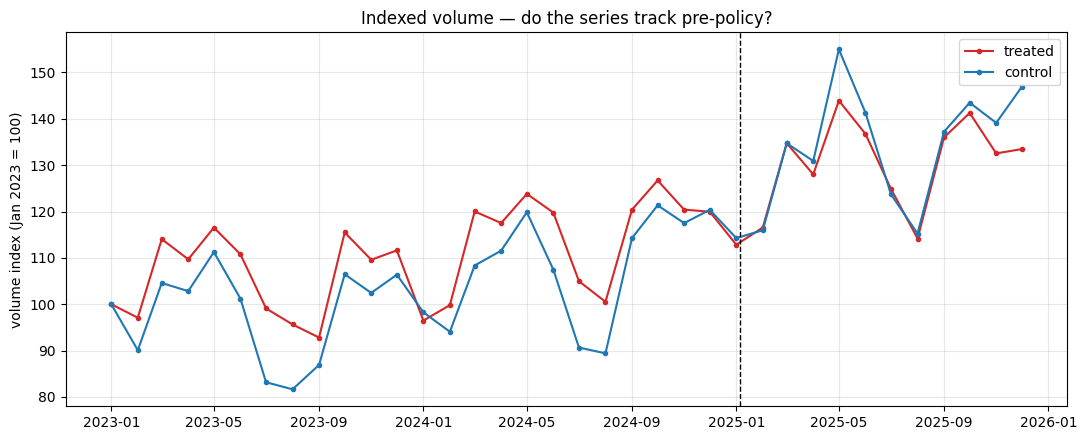

In [ ]:
def plot_indexed(m):
    wide = m.pivot(index="month", columns="group", values="trips")
    idx = wide / wide.iloc[0] * 100
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(idx.index, idx["treated"], label="treated", color="tab:red", marker=".")
    ax.plot(idx.index, idx["control"], label="control", color="tab:blue", marker=".")
    ax.axvline(POLICY_DATE, color="k", ls="--", lw=1)
    ax.set_ylabel("volume index (Jan 2023 = 100)"); ax.legend(); ax.grid(alpha=.3)
    ax.set_title("Indexed volume — do the series track pre-policy?")
    fig.tight_layout(); plt.show()

plot_indexed(m)

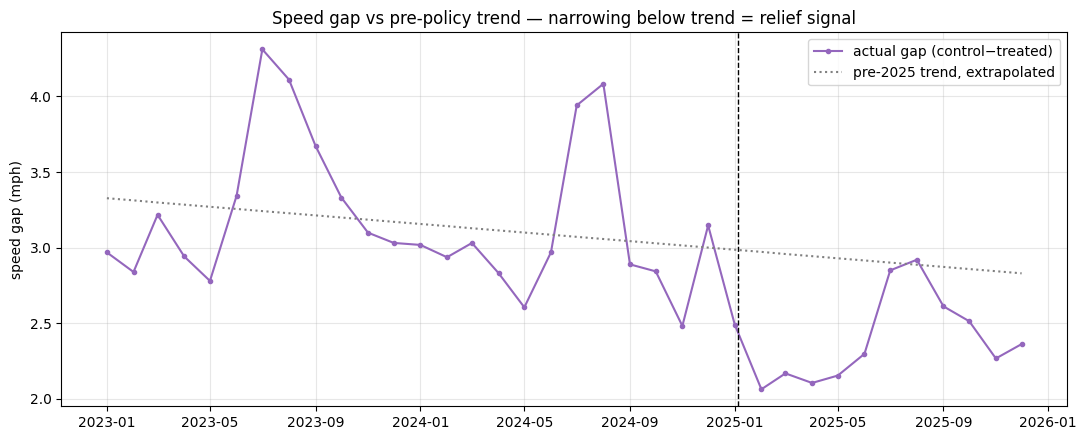

Pre-2025 gap slope: -0.014 mph/month
Mean 2025 deviation from extrapolated trend: -0.509 mph (negative = treated faster than trend predicts)


In [ ]:
def plot_speed_gap(m):
    wide = m.pivot(index="month", columns="group", values="speed")
    gap  = (wide["control"] - wide["treated"]).dropna()
    pre  = gap[gap.index < POLICY_DATE]
    x    = np.arange(len(gap))
    xpre = x[:len(pre)]
    b, a = np.polyfit(xpre, pre.values, 1)            # slope, intercept on pre-period
    trend = a + b * x
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(gap.index, gap.values, color="tab:purple", marker=".", label="actual gap (control−treated)")
    ax.plot(gap.index, trend, color="gray", ls=":", label="pre-2025 trend, extrapolated")
    ax.axvline(POLICY_DATE, color="k", ls="--", lw=1)
    ax.set_ylabel("speed gap (mph)"); ax.legend(); ax.grid(alpha=.3)
    ax.set_title("Speed gap vs pre-policy trend — narrowing below trend = relief signal")
    fig.tight_layout(); plt.show()
    post = gap[gap.index >= POLICY_DATE]
    resid = post.values - (a + b * x[len(pre):])
    print(f"Pre-2025 gap slope: {b:+.3f} mph/month")
    print(f"Mean 2025 deviation from extrapolated trend: {resid.mean():+.3f} mph "
          f"(negative = treated faster than trend predicts)")

plot_speed_gap(m)

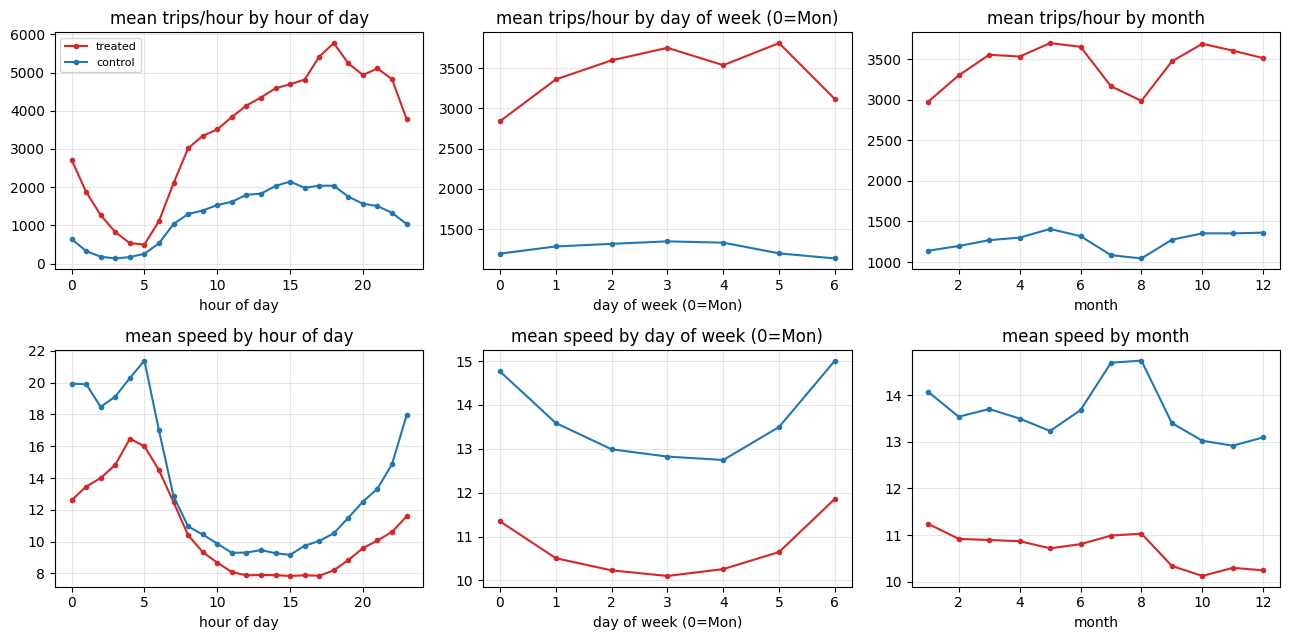

In [ ]:
def plot_seasonal(panel):
    p = panel.copy()
    p["hour"] = p.datetime.dt.hour
    p["dow"]  = p.datetime.dt.dayofweek      # 0=Mon
    p["mon"]  = p.datetime.dt.month
    fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
    keys = [("hour", "hour of day"), ("dow", "day of week (0=Mon)"), ("mon", "month")]
    for j, (k, lab) in enumerate(keys):
        for g, c in [("treated", "tab:red"), ("control", "tab:blue")]:
            d = p[p.group == g]
            axes[0, j].plot(d.groupby(k)["n_trips"].mean(), color=c, marker=".", label=g)
            axes[1, j].plot(d.groupby(k)["speed_median_mph"].mean(), color=c, marker=".", label=g)
        axes[0, j].set_title(f"mean trips/hour by {lab}")
        axes[1, j].set_title(f"mean speed by {lab}")
        for r in (0, 1):
            axes[r, j].grid(alpha=.3); axes[r, j].set_xlabel(lab)
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout(); plt.show()

plot_seasonal(panel)

In [ ]:
# Coverage, DST artefacts, and month-over-month anomalies
span = pd.date_range(panel.datetime.min(), panel.datetime.max(), freq="h")
present = panel.datetime.nunique()
print(f"Hourly coverage: {present}/{len(span)} ({100*present/len(span):.2f}%)  "
      f"[≈1 missing/yr = DST spring-forward]")

# very-low-volume hours (possible gaps masquerading as data)
low = panel.groupby("datetime")["n_trips"].sum()
print("Hours with <50 total trips:", int((low < 50).sum()))

# month-over-month % change z-scores — flags reporting cliffs
mt = m.pivot(index="month", columns="group", values="trips").pct_change()
z  = (mt - mt.mean()) / mt.std()
flagged = z[(z.abs() > 2.5).any(axis=1)]
print("\nMonths with anomalous MoM volume change (|z|>2.5):",
      "none" if flagged.empty else "")
if not flagged.empty:
    print(flagged.round(2).to_string())

Hourly coverage: 26301/26304 (99.99%)  [≈1 missing/yr = DST spring-forward]
Hours with <50 total trips: 8

Months with anomalous MoM volume change (|z|>2.5): none


In [ ]:
import os, pandas as pd
DATA_DIR = "/content/drive/MyDrive/nyc-crz-counterfactual"
panel = pd.read_parquet(os.path.join(DATA_DIR, "crz_hourly_panel_yellow_3grp.parquet"))
panel["datetime"] = pd.to_datetime(panel["datetime"])

m = (panel.assign(year=panel.datetime.dt.year)
          .groupby(["year", "group"])
          .agg(trips=("n_trips", "sum"),
               speed=("speed_median_mph", "mean")).reset_index())

vol = m.pivot(index="year", columns="group", values="trips")
print("Yearly trips (millions):")
print((vol / 1e6).round(2).to_string())
print("\nYoY % growth:")
print((vol.pct_change() * 100).round(1).to_string())
print("\nMean median-speed by year (mph):")
print(m.pivot(index="year", columns="group", values="speed").round(2).to_string())

Yearly trips (millions):
group  buffer  control  treated
year                           
2023     4.90     4.68    27.34
2024     5.22     5.31    29.44
2025     5.58     7.43    33.41

YoY % growth:
group  buffer  control  treated
year                           
2023      NaN      NaN      NaN
2024      6.5     13.4      7.7
2025      7.0     39.8     13.5

Mean median-speed by year (mph):
group  buffer  control  treated
year                           
2023    12.12    16.69    11.01
2024    11.67    15.50    10.49
2025    11.55    14.29    10.62
